## Dessicant Wheel Control

In [104]:
import pysr
import sympy
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from pysr import PySRRegressor
default_pysr_params = dict(
    populations=100,
    model_selection="accuracy",
    population_size = 100,
    niterations=30,
    binary_operators=["+", "*", "^"],
    unary_operators=["sin","cos","exp", "log","erf", "ceil", "floor"],
    maxsize=50,
    ncycles_per_iteration=100,
    progress=False,
)
# Control Dataset
Control_XLS = pd.ExcelFile('../Control/DessicantControlTests.xlsx')
Control_Dataframe = pd.read_excel(Control_XLS, 'Average')
# Proto Dataset
Proto_XLS = pd.ExcelFile('../Proto/ProtoTests.xlsx')
Proto_Dataframe = pd.read_excel(Proto_XLS, 'Average')

C_x = Control_Dataframe["Cumulative WattHours (WH)"].to_numpy().reshape(-1,1)
C_y = Control_Dataframe["Water Level (mL)"].to_numpy()
C_z = Control_Dataframe["Temp (C)"].to_numpy()
P_x = Proto_Dataframe["Cumulative WattHours (WH)"].to_numpy().reshape(-1,1)
P_y = Proto_Dataframe["Water Level (mL)"].to_numpy()
P_z = Proto_Dataframe["Temp (C)"].to_numpy()

In [75]:
# Run PySR
Control_Equations = PySRRegressor(
    **default_pysr_params,
)
Control_Equations.fit(C_x,C_y)

C:\Users\JohnSi\AppData\Local\Programs\Python\Python312\Lib\site-packages\pysr\sr.py:1231: UserWarning: Note: Using a large maxsize for the equation search will be exponentially slower and use significant memory.
  warnings.warn(
C:\Users\JohnSi\AppData\Local\Programs\Python\Python312\Lib\site-packages\pysr\sr.py:65: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://astroautomata.com/PySR/tuning/
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 1.510e+04
Head worker occupation: 61.8%. This is high, and will prevent efficient resource usage. Increase `ncycles_per_iteration` to reduce load on head worker.
Progress: 50 / 3000 total iterations (1.667%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
2           1.772e+01  7.971e+00  y = exp(1.9986)
3           1.762e+01  5.567e-03  y = floor(exp(2.108))
4           1.623e-01  4.687e+00  y = ceil(x₀ * 0.15674)
5           1.586e-01  2.308e-02  y = floor(ceil(x₀ * 0.15616))
7           1.538e-01  1.535e-02  y = log(ceil(1.18 ^ ceil(floor(x₀))))
8           1.022e-01  4.087e-01  y = (x₀ * erf(-1.0022)) + (0.4909 + x₀)
10          7.710e-02  1.410e-01  y = ((x₀ * erf(-1.0981)) + (0.80521 + x₀)) ^ 1.0951
---------------------------------------------------------------------------------------------------
Press 'q' and then <enter> to stop executi

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                     exp(1.9985965)   
	1         4.698297                                    x0 * 0.16431619   
	2         0.111044                              0.16303697 * ceil(x0)   
	3         0.345900                      0.15641871 * (x0 + 3.1244714)   
	4         0.009944                  0.15632823 * ceil(x0 + 2.6435018)   
	5         0.289487        ((x0 * 0.10024737) + 0.9200918) ^ 1.1720089   
	6         0.043813  ((x0 * 0.10024737) + ceil(0.10024737)) ^ 1.172...   
	7         0.168686  0.9487985 + (x0 * (0.1269212 + (x0 * 0.0003169...   
	8         0.050090  erf(x0) + (x0 * ((0.0003365594 * x0) + 0.12472...   
	9         0.112383  0.88906616 + (x0 * ((x0 * (x0 * 2.4760868e-6))...   
	10        0.031711  erf(x0) + (x0 * (0.13378735 + ((x0 * x0) * 2.7...   
	11        0.004728  erf(floor(x0)) + (x0 * ((2.7785293e-6 * (x0 * ...   
	12        0.097069  erf(x0 * 0.16431619) + (x0 * (((x0 * x0) * 2.7...   
	13        0.075731  ((x0 + cos(sin(log(x0)) + -0.33005708)) + (erf...   
	14        0.008530  ((cos(sin(log(x0 + -0.37942585)) + -0.3292131)...   
	15        0.056543  ((cos(cos((x0 + exp(-0.7071114)) + (erf(-1.410...   
	16        0.000048  ((cos(cos((x0 + exp(-0.7071114)) + (erf(-1.410...   
	17        0.001745  ((cos(cos((x0 + exp(-0.7071114)) + (erf(-1.410...   
	18        0.010993  ((cos(cos((exp(sin(-0.8740598)) + x0) + (erf(-...   
	19        0.000347  ((cos(cos((exp(sin(-0.8740598)) + x0) + (erf(-...   
	20  >>>>  0.001128  ((erf(-1.0999476) * x0) + (cos((0.030475669 ^ ...   
	
	         loss  complexity  
	0   17.719984           2  
	1    0.161443           3  
	2    0.144475           4  
	3    0.102228           5  
	4    0.101217           6  
	5    0.075776           7  
	6    0.072527           8  
	7    0.061269           9  
	8    0.058276          10  
	9    0.052081          11  
	10   0.050456          12  
	11   0.050218          13  
	12   0.045572          14  
	13   0.042248          15  
	14   0.041534          17  
	15   0.035054          20  
	16   0.035050          22  
	17   0.034928          24  
	18   0.034546          25  
	19   0.034534          26  
	20   0.034495          27  
]

Power:0.003055499438317472
Temp:2.9918445133812783
Voltage:0.05278622414544921
Water:4.191422343549114
\left(0.120 x_{0} + \cos{\left(0.0305^{0.646 x_{0}} + \cos{\left(0.0464 x_{0} + 0.474 \right)} \right)}\right)^{1.10}


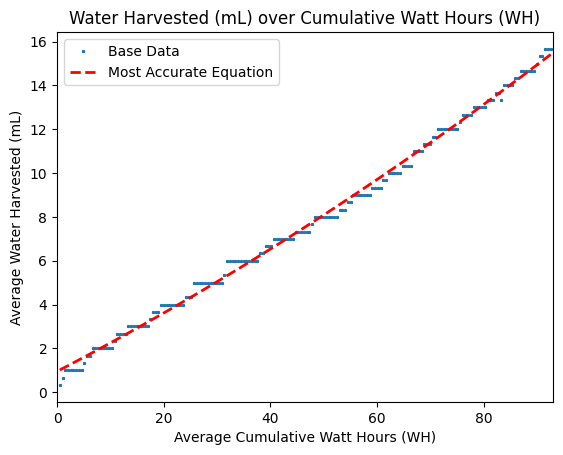

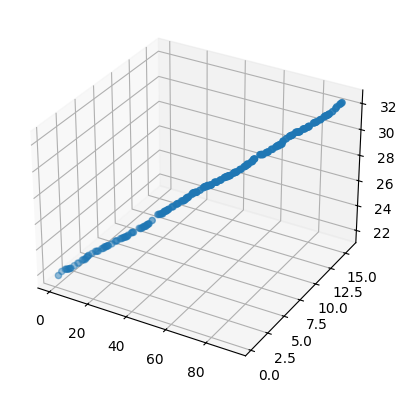

In [98]:
plt.plot(C_x, C_y, linewidth = 2, linestyle='none', marker='*', label="Base Data", fillstyle='none', markersize=2)
best_idx = Control_Equations.equations_.query(
    f"loss < {2 * Control_Equations.equations_.loss.min()}"
).score.idxmax()
plt.plot(C_x, Control_Equations.predict(C_x, index=best_idx), color='red', linestyle='dashed', linewidth=2, label="Most Accurate Equation")
plt.title("Water Harvested (mL) over Cumulative Watt Hours (WH)")
plt.xlabel("Average Cumulative Watt Hours (WH)")
plt.ylabel("Average Water Harvested (mL)")
plt.legend()
plt.xlim([0,93])
print("Power:" + str(np.std(Control_Dataframe["WattHours (WH)"].to_numpy())))
print("Temp:" + str(np.std(C_z)))
print("Voltage:" + str(np.std(Control_Dataframe["Volts (V)"].to_numpy())))
print("Water:" + str(np.std(C_y)))
print(Control_Equations.latex())
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter3D(C_x, C_y, C_z)

In [99]:
# Run PySR
Proto_Equations = PySRRegressor(
    **default_pysr_params,
)
Proto_Equations.fit(P_x,P_y)

C:\Users\JohnSi\AppData\Local\Programs\Python\Python312\Lib\site-packages\pysr\sr.py:1231: UserWarning: Note: Using a large maxsize for the equation search will be exponentially slower and use significant memory.
  warnings.warn(
C:\Users\JohnSi\AppData\Local\Programs\Python\Python312\Lib\site-packages\pysr\sr.py:65: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://astroautomata.com/PySR/tuning/
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 1.390e+04
Head worker occupation: 63.4%. This is high, and will prevent efficient resource usage. Increase `ncycles_per_iteration` to reduce load on head worker.
Progress: 47 / 3000 total iterations (1.567%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
2           6.996e+00  7.971e+00  y = log(x₀)
3           6.963e-02  4.610e+00  y = x₀ * 0.18877
5           6.273e-02  5.217e-02  y = exp(-1.6824) * ceil(x₀)
6           5.197e-02  1.882e-01  y = (0.18081 * x₀) + erf(0.24208)
7           5.034e-02  3.185e-02  y = ((0.25597 * x₀) + -0.13982) ^ 0.86186
8           4.547e-02  1.016e-01  y = (floor(ceil(x₀)) * exp(-1.5395)) ^ 0.93048
---------------------------------------------------------------------------------------------------
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 1.640e+04
Head worker occupati

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                                 x0   
	1         4.397046                                      exp(1.580093)   
	2         4.599025                                    0.18877071 * x0   
	3         0.104332                              0.18592255 * ceil(x0)   
	4         0.425460                     (x0 * 0.22758512) ^ 0.91108906   
	5         0.000007                (x0 * 0.22747557) ^ cos(0.42438257)   
	6         0.061361           (0.21219443 + (x0 * -0.0006189013)) * x0   
	7         0.000339    x0 * (0.21186118 + (-0.0006178447 * floor(x0)))   
	8         0.107948  ((cos(x0 * 0.92565113) + x0) * 0.22770597) ^ 0...   
	9         0.031085  ((erf(cos(x0 * 0.92565113)) + x0) * 0.22770597...   
	10        0.051732  ((floor(cos(x0 * 0.92565113)) + x0) * exp(-1.4...   
	11        0.006562  sin((ceil(0.04713621 * x0) * -0.009860177) + 0...   
	12        0.003275  (exp(-1.720844) * ((ceil(0.3156967 * x0) + x0)...   
	13        0.003019  (exp(-1.6509328) * ((ceil(0.23416255 * (x0 + c...   
	14        0.030660  (exp(-1.7230272) * ((floor(cos(x0 * 0.92565113...   
	15        0.021013  (exp(-1.7230272) * ((floor(cos(x0 * 0.92565113...   
	16        0.005248  (exp(-1.7230272) * ((floor(cos((x0 + 0.6008535...   
	17        0.023352  (exp(-1.7230272) * ((floor(cos((x0 + 0.6008535...   
	18        0.003321  (exp(-1.7230272) * ((floor(cos((x0 + 0.6008535...   
	19  >>>>  0.006974  (exp(-1.7230272) * ((x0 + ceil(0.32605657 * ce...   
	
	          loss  complexity  
	0   561.967500           1  
	1     6.919876           2  
	2     0.069625           3  
	3     0.062727           4  
	4     0.040990           5  
	5     0.040990           6  
	6     0.038550           7  
	7     0.038537           8  
	8     0.031054          10  
	9     0.030104          11  
	10    0.028586          12  
	11    0.027845          16  
	12    0.027393          21  
	13    0.027310          22  
	14    0.026486          23  
	15    0.025935          24  
	16    0.025799          25  
	17    0.025204          26  
	18    0.025037          28  
	19    0.024519          31  
]

Power:0.2785496658115589
Temp:0.14768078479453892
Voltage:0.07833377112214612
Water:2.6305658218736663
0.287 \left(0.718 x_{0} + 0.718 \left\lceil{0.326 \left\lceil{x_{0} + \left\lfloor{\cos{\left(x_{0} \right)}}\right\rfloor - 0.498}\right\rceil}\right\rceil + \left\lfloor{\cos{\left(0.901 x_{0} + 0.542 \right)}}\right\rfloor\right)^{0.897}


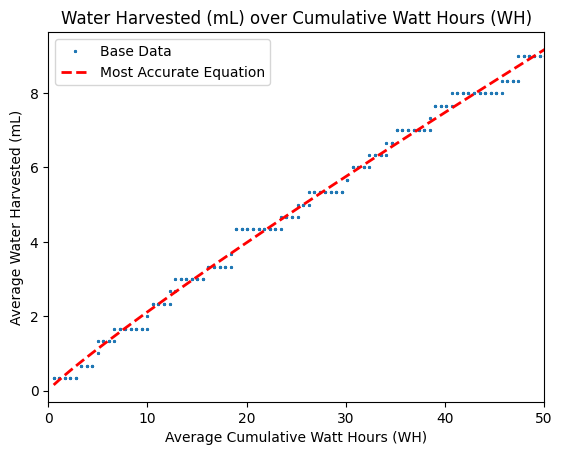

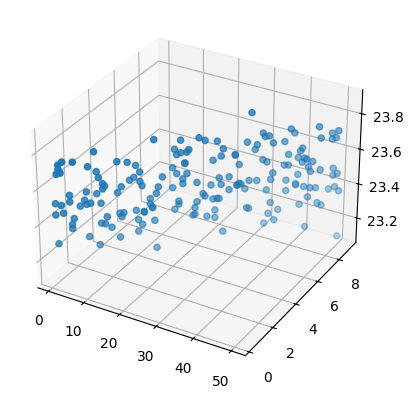

In [110]:
plt.plot(P_x, P_y, linewidth = 2, linestyle='none', marker='*', label="Base Data", fillstyle='none', markersize=2)
best_idx = Proto_Equations.equations_.query(
    f"loss < {2 * Proto_Equations.equations_.loss.min()}"
).score.idxmax()
plt.plot(P_x, Proto_Equations.predict(P_x, index=best_idx), color='red', linestyle='dashed', linewidth=2, label="Most Accurate Equation")
plt.title("Water Harvested (mL) over Cumulative Watt Hours (WH)")
plt.xlabel("Average Cumulative Watt Hours (WH)")
plt.ylabel("Average Water Harvested (mL)")
plt.legend()
plt.xlim([0,50])
Proto_Equations.sympy()
print("Power:" + str(np.std(Proto_Dataframe["WattHours (WH)"].to_numpy())))
print("Temp:" + str(np.std(P_z)))
print("Voltage:" + str(np.std(Proto_Dataframe["Volts (V)"].to_numpy())))
print("Water:" + str(np.std(P_y)))
print(Proto_Equations.latex())
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter3D(P_x, P_y, P_z)